# 01 - Exploratory Data Analysis

## Objective
Explore the Club Piscine franchise sales data and build the weekly aggregation
for modelling.

## Primary Data Source
Sliced Power BI exports — one Excel file per store in `data/raw/slices/data*.xlsx`

**8 columns per file:**
| Column | Role |
|---|---|
| `Date de Vente` | Sale date |
| `Quantité facturée` | Units sold → **unit demand target** |
| `Division Code corrigée` | Product division (corrected, 11 active) |
| `Magasins` | Store code + name e.g. "CP05 - Sherbrooke" |
| `_Montant Facture` | Line revenue CAD → renamed `revenue` |
| `Catégorie` | Sub-category within division |
| `Répliqué-Franchisé` | 1 = shared catalogue, 0 = local purchase |
| `No. Article` | Item code |


## Active Stores: 29
CP02 CP04 CP05 CP06 CP07 CP08 CP10 CP12 CP13 CP15 CP16 CP17 CP18 CP202
CP28 CP32 CP33 CP35 CP36 CP37 CP39 CP40 CP44 CP45 CP46 CP47 CP48 CP77 CP100

## Active Divisions: 11
FI BQ GA ME PA CH HT TO PC LO SP

## Outputs
- `data/processed/weekly_units.csv` — Weekly × Store × Division (units + revenue)
- `data/processed/store_region_map.csv` — Store → city mapping
---


---
## Cell 1: Imports and Setup
---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette('husl')

PROJECT_ROOT    = Path('..')
DATA_RAW        = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED  = PROJECT_ROOT / 'data' / 'processed'
FIGURES         = PROJECT_ROOT / 'reports' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: Load Raw Data
---

In [30]:
# ── Load sliced Power BI exports ──────────────────────────────────────────────
# Each file covers one store: data/raw/slices/CP*.xlsx
# Columns in each file:
#   Date de Vente | Quantité facturée | Division Code corrigée | Magasins


# ── 2: All sliced files (production) ────────────────────────────────────────
import glob

slice_files = sorted(glob.glob(str(DATA_RAW / 'slices' / 'data*.xlsx')))
if len(slice_files) == 0:
    raise FileNotFoundError(
        f"No slice files found in {DATA_RAW / 'slices'}/. "
        "Place one Excel file per store there (e.g. CP02.xlsx, CP04.xlsx ...)."
    )

parts = []
for fp in slice_files:
    df_s = pd.read_excel(fp)
    df_s['_source_file'] = Path(fp).name
    parts.append(df_s)

vente_raw = pd.concat(parts, ignore_index=True)
print(f"Loaded {len(slice_files)} slice files → {len(vente_raw):,} rows")
print(f"Columns: {vente_raw.columns.tolist()}")

# ── Standardise column names ──────────────────────────────────────────────────
# 'Magasins' = 'CP05 - Sherbrooke' → split into store_code and store_name
vente_raw[['No. magasin', 'store_name']] = (
    vente_raw['Magasins']
    .str.split(' - ', n=1, expand=True)
)
# Rename _Montant Facture → revenue for cleaner downstream references
vente = vente_raw.rename(columns={
    '_Montant Facture': 'revenue',
}).copy()

# Convert date — use errors='coerce' so non-date values (e.g. "Total" summary rows
# that Power BI appends at the bottom of exports) become NaT instead of crashing
vente['Date de Vente'] = pd.to_datetime(vente['Date de Vente'], errors='coerce')

# Drop the summary/total rows and any other unparseable dates
bad_dates = vente['Date de Vente'].isna().sum()
if bad_dates:
    print(f"  Dropped {bad_dates} rows with unparseable dates (e.g. 'Total' summary rows)")
vente = vente.dropna(subset=['Date de Vente']).copy()
vente['Quantité facturée'] = pd.to_numeric(vente['Quantité facturée'], errors='coerce').fillna(0)

# Drop rows with missing division code or store (can occur at bottom of some exports)
before = len(vente)
vente = vente.dropna(subset=['Division Code corrigée', 'No. magasin']).copy()
vente['Division Code corrigée'] = vente['Division Code corrigée'].astype(str).str.strip()
vente['No. magasin'] = vente['No. magasin'].astype(str).str.strip()
if len(vente) < before:
    print(f"  Dropped {before - len(vente)} rows with missing Division Code or Magasins")

# Load supporting tables (still needed for store/city mapping and calendar)
# ── Supporting tables (all optional — pipeline runs without them) ─────────────
# Table_Magasins: used for franchise group labels in store map (city comes from slices)
try:
    magasins = pd.read_excel(DATA_RAW / 'Table_Magasins.xlsx')
    print("✓ Table_Magasins loaded")
except FileNotFoundError:
    # Build minimal magasins from slice data
    magasins = pd.DataFrame({
        'Codes magasins': list(STORE_CITY_MAP.keys()),
        'Ville magasins': list(STORE_CITY_MAP.values()),
        'Regroupement': list(STORE_CITY_MAP.keys()),
        'Nom Regroupement': [f'CP{k[2:]} - {v}' for k, v in STORE_CITY_MAP.items()],
    })
    print("⚠ Table_Magasins.xlsx not found — using slice-derived store map")



print(f"\nVente (combined slices)  : {vente.shape[0]:,} rows × {vente.shape[1]} cols")
print(f"Stores in data           : {sorted(vente['No. magasin'].dropna().astype(str).unique())}")
print(f"Divisions in data        : {sorted(vente['Division Code corrigée'].dropna().astype(str).unique())}")
print(f"Date range               : {vente['Date de Vente'].min().date()} → {vente['Date de Vente'].max().date()}")
print(f"\nColumns available: Date de Vente, Quantité facturée, Division Code corrigée,")
print(f"                   Magasins, _Montant Facture (→ revenue), Catégorie,")
print(f"                   Répliqué-Franchisé, No. Article")


Loaded 33 slice files → 1,991,675 rows
Columns: ['Date de Vente', 'Quantité facturée', 'Division Code corrigée', 'Magasins', 'Répliqué-Franchisé', 'No. Article', 'Catégorie', '_Montant Facture', '_source_file']
  Dropped 99 rows with unparseable dates (e.g. 'Total' summary rows)
  Dropped 1455 rows with missing Division Code or Magasins
✓ Table_Magasins loaded

Vente (combined slices)  : 1,990,121 rows × 11 cols
Stores in data           : ['CP01', 'CP02', 'CP04', 'CP05', 'CP06', 'CP07', 'CP08', 'CP10', 'CP11', 'CP12', 'CP13', 'CP15', 'CP16', 'CP17', 'CP18', 'CP20', 'CP202', 'CP28', 'CP29', 'CP32', 'CP33', 'CP35', 'CP36', 'CP37', 'CP39', 'CP40', 'CP43', 'CP44', 'CP45', 'CP46', 'CP47', 'CP48', 'CP77']
Divisions in data        : ['AB', 'AM', 'AP', 'AS', 'AZ', 'BI', 'BQ', 'CA', 'CC', 'CH', 'CM', 'CR', 'DI', 'DO', 'FI', 'GA', 'HT', 'IN', 'INM', 'LI', 'LO', 'ME', 'MK', 'NO', 'PA', 'PB', 'PC', 'PI', 'SA', 'SE', 'SEC', 'SP', 'THM', 'TO']
Date range               : 2023-11-02 → 2026-03-19

Colu

---
## Cell 3: Store List & Region Mapping
---

In [31]:
store_map = magasins[['Codes magasins','Ville magasins','Regroupement','Nom Regroupement']].copy()
store_map.columns = ['store_code','city','franchise_group','franchise_name']

# ── Store exclusions (client instructions, March 2026) ────────────────────────
# Removed by client: 'CP01', 'CP03', 'CP11','CP20', 'CP21', 'CP23', 'CP29', 'CP31', 'CP41', 'CP43', 'CP49'
# Final store list per client 
# CP77 (Liquidation) → treated as Laval (CP07 regroupement)
# CP100 (Liquidation) → treated as Saint-Jérôme (CP10 regroupement)
EXCLUDE_STORES = {
    'CP01', 'CP03', 'CP11','CP20', 'CP21', 'CP23', 'CP29', 'CP31', 'CP41', 'CP43', 'CP49'   # client removal request 
}
# Stores with no FY2024 (CP05, CP12, CP18, CP40, CP47) are now INCLUDED
# per updated client instructions — they have data in the new exports

active_stores = [s for s in vente['No. magasin'].unique() if s not in EXCLUDE_STORES]
vente         = vente[vente['No. magasin'].isin(active_stores)].copy()
store_map_active = store_map[store_map['store_code'].isin(active_stores)].copy()

print(f'Stores after exclusions: {len(active_stores)} (excluded: {sorted(EXCLUDE_STORES)})')
print()
print(store_map_active[['store_code','city','franchise_name']].to_string(index=False))
store_map_active.to_csv(DATA_PROCESSED / 'store_region_map.csv', index=False)
print("\n✅ Saved: store_region_map.csv")


Stores after exclusions: 28 (excluded: ['CP01', 'CP03', 'CP11', 'CP20', 'CP21', 'CP23', 'CP29', 'CP31', 'CP41', 'CP43', 'CP49'])

store_code                     city                  franchise_name
      CP04            Drummondville            CP04 - Drummondville
      CP05               Sherbrooke               CP05 - Sherbrooke
      CP06                   Granby                   CP06 - Granby
      CP32             St-Hyacinthe                   CP06 - Granby
      CP45              Cowansville                   CP06 - Granby
      CP07                    Laval                    CP07 - Laval
      CP02               Blainville                    CP07 - Laval
      CP77              Liquidation                    CP07 - Laval
      CP08                Longueuil                CP08 - Longueuil
      CP44              St-Constant                CP08 - Longueuil
      CP48                  Beloeil                CP08 - Longueuil
      CP10             Saint-Jérôme             CP10 -

In [32]:
# ── Division whitelist — applied before any EDA so all visuals reflect final scope ──
FINAL_DIVS = {'FI','BQ','GA','ME','PA','CH','HT','TO','PC','LO','SP'}

# Merge INM into IN then apply whitelist
vente['Division Code corrigée'] = vente['Division Code corrigée'].replace({'INM': 'IN'})
vente = vente[vente['Division Code corrigée'].isin(FINAL_DIVS)].copy()

print(f'After division whitelist: {len(vente):,} rows')
print(f'Active divisions ({len(FINAL_DIVS)}): {sorted(vente["Division Code corrigée"].unique())}')
print(f'Active stores    ({vente["No. magasin"].nunique()}): {sorted(vente["No. magasin"].unique())}')


After division whitelist: 807,482 rows
Active divisions (11): ['BQ', 'CH', 'FI', 'GA', 'HT', 'LO', 'ME', 'PA', 'PC', 'SP', 'TO']
Active stores    (28): ['CP02', 'CP04', 'CP05', 'CP06', 'CP07', 'CP08', 'CP10', 'CP12', 'CP13', 'CP15', 'CP16', 'CP17', 'CP18', 'CP202', 'CP28', 'CP32', 'CP33', 'CP35', 'CP36', 'CP37', 'CP39', 'CP40', 'CP44', 'CP45', 'CP46', 'CP47', 'CP48', 'CP77']


---
## Cell 4: Product Catalogue Enrichment (ITEM_TOTAL)

**Join key:** `Vente['No. d'article']` ↔ `ITEM_TOTAL['No. Article']`
**Join rate: 100%** — every article in the sales extract exists in the catalogue.

This adds:
- `Catégorie` — finer grain than Division (177 unique values vs 26 divisions)
- `Groupe de produit` — finest grain (435 groups), for future SKU-level forecasting
- `Répliqué-Franchisé` — flag to distinguish shared catalogue (1) from local purchases (0)
---

In [33]:
# ── Catégorie and article info are now in the slice files directly ────────────
# No separate ITEM_TOTAL join needed.

# Verify coverage
cat_null = vente['Catégorie'].isna().sum()
art_null = vente["No. Article"].isna().sum()
print(f"Catégorie coverage : {len(vente) - cat_null:,} / {len(vente):,} rows ({(1-cat_null/len(vente)):.1%})")
print(f"No. Article coverage: {len(vente) - art_null:,} / {len(vente):,} rows ({(1-art_null/len(vente)):.1%})")
print(f"Unique Catégories  : {vente['Catégorie'].nunique()}")
print(f"Unique Articles    : {vente['No. Article'].nunique()}")


Catégorie coverage : 717,340 / 807,482 rows (88.8%)
No. Article coverage: 807,482 / 807,482 rows (100.0%)
Unique Catégories  : 106
Unique Articles    : 28187


In [34]:
print('='*60)
print('TOP CATEGORIES BY REVENUE')
print('='*60)
cat_summary = (
    vente.groupby(['Division Code corrigée','Catégorie'])
         .agg(total_revenue = ('revenue',            'sum'),
              total_units   = ('Quantité facturée',  'sum'),
              transactions  = ('revenue',            'count'))
         .sort_values('total_revenue', ascending=False)
         .reset_index()
)
print(cat_summary.head(30).to_string(index=False))


TOP CATEGORIES BY REVENUE
Division Code corrigée Catégorie  total_revenue  total_units  transactions
                    SP        SP    36878423.96      3905.00          3923
                    PC       PIS    31148748.81   1336263.50        262526
                    CH       THE    18793285.37      9515.00          8257
                    HT       HRE    17765353.83      4976.00          5276
                    GA       GRS    10048428.03      5727.00          5051
                    ME        M4     8460324.65     46251.00         14274
                    ME        M5     7429034.02     14757.00         13144
                    GA       GRB     6907094.27       636.00           647
                    ME        M1     6855936.28      4958.00          4428
                    PC       SPA     6452157.05    312854.00        167737
                    HT       HAC     5377574.71      2245.00          2178
                    GA        GA     4037834.01      9722.96          8863

In [35]:
print('='*60)
print('SHARED CATALOGUE vs LOCAL PURCHASES (Répliqué-Franchisé)')
print('='*60)
rep_summary = (
    vente.groupby('Répliqué-Franchisé')
         .agg(total_revenue = ('revenue',           'sum'),
              total_units   = ('Quantité facturée', 'sum'),
              transactions  = ('revenue',           'count'))
         .reset_index()
)
rep_summary['Répliqué-Franchisé'] = rep_summary['Répliqué-Franchisé'].map({1: 'Shared (1)', 0: 'Local (0)'})
print(rep_summary.to_string(index=False))


SHARED CATALOGUE vs LOCAL PURCHASES (Répliqué-Franchisé)
Répliqué-Franchisé  total_revenue  total_units  transactions
         Local (0)     9585238.71     87152.50         37849
        Shared (1)   197511937.59   2013573.56        679540


---
## Cell 6: Division Code Breakdown
---

In [36]:
print('='*60)
print('DIVISION CODES — REVENUE & UNITS BREAKDOWN')
print('='*60)
div_summary = (
    vente.groupby('Division Code corrigée')
         .agg(
             transactions  = ('Quantité facturée', 'count'),
             total_revenue = ('revenue',           'sum'),
             total_units   = ('Quantité facturée', 'sum'),
         )
         .sort_values('total_revenue', ascending=False)
         .reset_index()
)
div_summary['pct_revenue'] = (div_summary['total_revenue'] / div_summary['total_revenue'].sum() * 100).round(1)
div_summary['pct_units']   = (div_summary['total_units']   / div_summary['total_units'].sum()   * 100).round(1)
print(div_summary.to_string(index=False))


DIVISION CODES — REVENUE & UNITS BREAKDOWN
Division Code corrigée  transactions  total_revenue  total_units  pct_revenue  pct_units
                    SP          7223    50492963.69      8557.00         21.1        0.4
                    ME        116409    47701492.40    217514.00         19.9        9.5
                    PC        485263    40829718.09   1782579.50         17.1       77.8
                    GA         18843    29993163.34     23418.06         12.5        1.0
                    HT         13682    28649784.94     12766.00         12.0        0.6
                    CH         10841    20013316.10     12520.00          8.4        0.5
                    BQ         21375     5940553.26     23600.00          2.5        1.0
                    TO         11413     5785166.63     12016.00          2.4        0.5
                    FI          8207     3926652.76     11083.50          1.6        0.5
                    PA         16134     3786515.68     17946.00   

---
## Cell 7: Data Coverage
---

In [37]:
print('='*60)
print('DATA COVERAGE')
print('='*60)
print(f'Overall: {vente["Date de Vente"].min().date()} → {vente["Date de Vente"].max().date()}')

# week_ending needed for coverage check — compute here if not yet present
if 'week_ending' not in vente.columns:
    vente['week_ending'] = (vente['Date de Vente'] + pd.offsets.Week(weekday=6)).dt.normalize()

print(f'Weeks  : {vente["week_ending"].nunique()}')

# Enrich with city from store_map_active (if not already merged)
if 'city' not in vente.columns:
    vente = vente.merge(
        store_map_active[['store_code','city','franchise_name']],
        left_on='No. magasin', right_on='store_code', how='left'
    ).drop(columns='store_code')

vente['month']      = vente['Date de Vente'].dt.month
vente['week_of_yr'] = vente['Date de Vente'].dt.isocalendar().week.astype(int)

store_cov = (
    vente.groupby(['No. magasin','city'])
         .agg(min_date     = ('Date de Vente',     'min'),
              max_date     = ('Date de Vente',     'max'),
              n_records    = ('Quantité facturée', 'count'),
              total_units  = ('Quantité facturée', 'sum'),
              total_revenue= ('revenue',           'sum'))
         .reset_index()
)
store_cov['weeks'] = ((store_cov['max_date']-store_cov['min_date']).dt.days/7).round(1)
print('\nCoverage by store:')
print(store_cov.to_string(index=False))


DATA COVERAGE
Overall: 2023-11-02 → 2026-03-19
Weeks  : 125

Coverage by store:
No. magasin                     city   min_date   max_date  n_records  total_units  total_revenue  weeks
       CP02               Blainville 2023-11-02 2026-03-19      35708     94780.00    10462600.21  124.0
       CP04            Drummondville 2023-11-02 2026-03-19      34344     86812.00     8189051.95  124.0
       CP05               Sherbrooke 2024-05-09 2026-03-19      28894     99758.00    13430085.89   97.0
       CP06                   Granby 2023-11-02 2026-03-19      49091    142276.00    16924906.71  124.0
       CP07                    Laval 2023-11-02 2026-03-19      63866    190472.00    25682481.06  124.0
       CP08                Longueuil 2023-11-02 2026-03-19      30743     95440.00     8406101.01  124.0
       CP10             Saint-Jérôme 2023-11-02 2026-03-19      47298    119907.00    15075095.25  124.0
       CP12     St-Georges-de-Beauce 2024-11-01 2026-03-17       8879     18626.

---
## Cell 9: Sales Visualizations
---

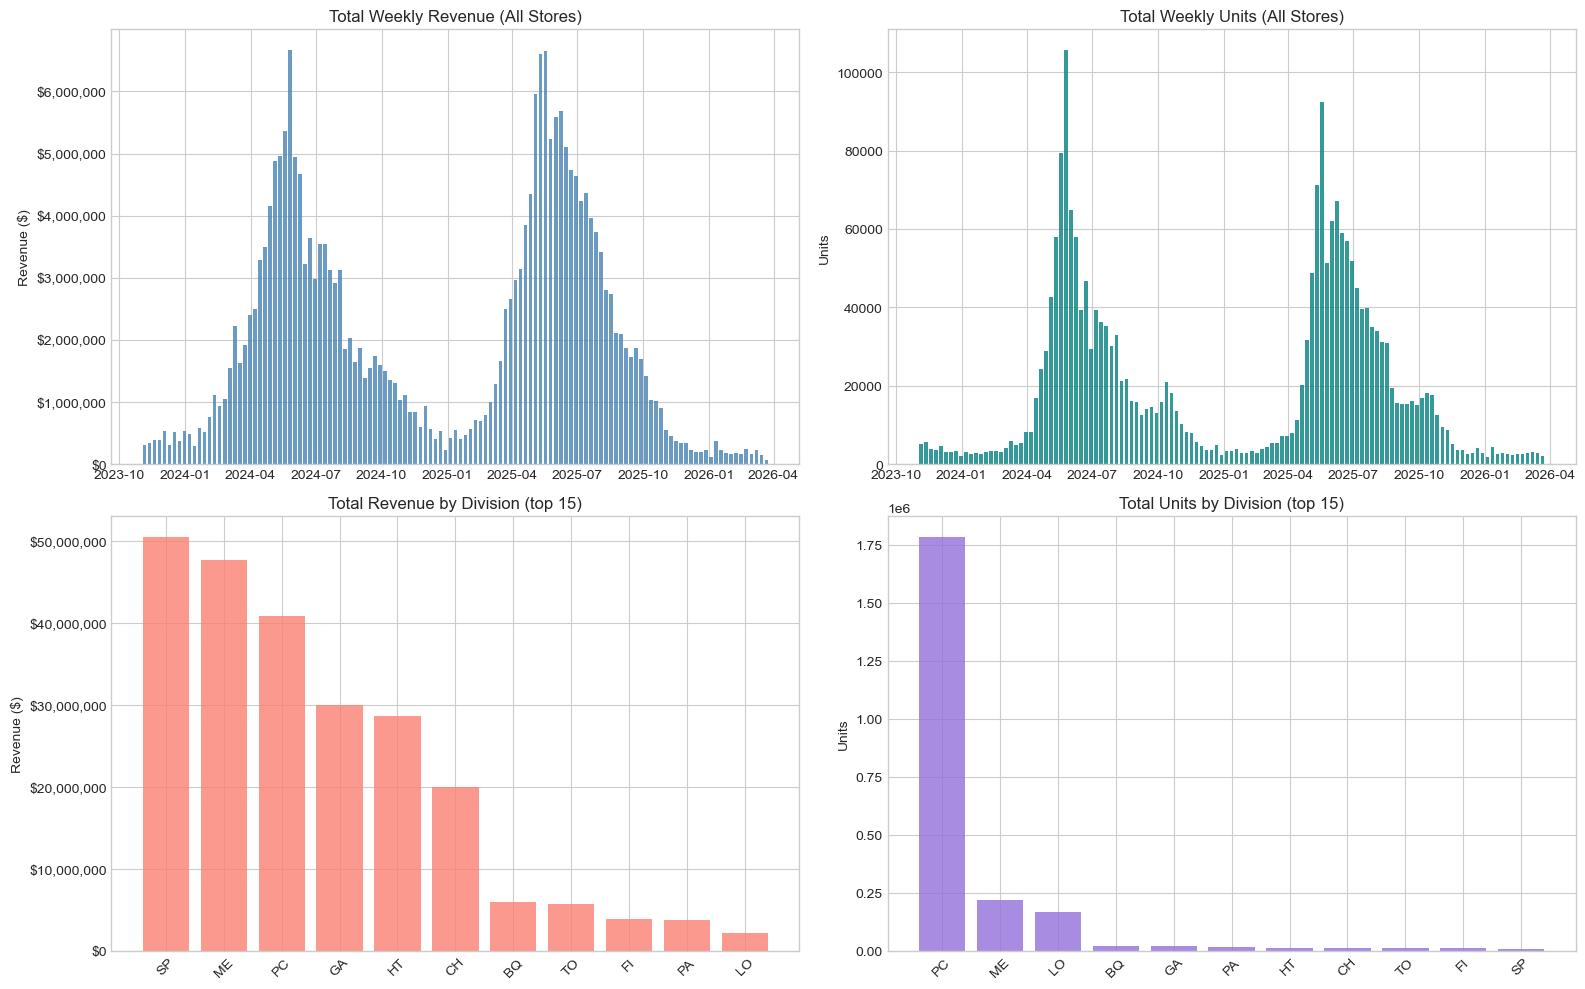

✅ Saved: sales_overview.png


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

vente_wk = vente.copy()
vente_wk['week_ending'] = vente_wk['Date de Vente'] + pd.offsets.Week(weekday=6)

# Weekly revenue — all stores
ax1 = axes[0, 0]
weekly_rev = vente_wk.groupby('week_ending')['revenue'].sum()
ax1.bar(weekly_rev.index, weekly_rev.values, color='steelblue', width=5, alpha=0.8)
ax1.set_title('Total Weekly Revenue (All Stores)')
ax1.set_ylabel('Revenue ($)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Weekly units — all stores
ax2 = axes[0, 1]
weekly_units = vente_wk.groupby('week_ending')['Quantité facturée'].sum()
ax2.bar(weekly_units.index, weekly_units.values, color='teal', width=5, alpha=0.8)
ax2.set_title('Total Weekly Units (All Stores)')
ax2.set_ylabel('Units')

# Revenue by division (top 15)
ax3 = axes[1, 0]
div_rev = vente.groupby('Division Code corrigée')['revenue'].sum().sort_values(ascending=False).head(15)
ax3.bar(div_rev.index, div_rev.values, color='salmon', alpha=0.8)
ax3.set_title('Total Revenue by Division (top 15)')
ax3.set_ylabel('Revenue ($)')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Units by division (top 15)
ax4 = axes[1, 1]
div_units = vente.groupby('Division Code corrigée')['Quantité facturée'].sum().sort_values(ascending=False).head(15)
ax4.bar(div_units.index, div_units.values, color='mediumpurple', alpha=0.8)
ax4.set_title('Total Units by Division (top 15)')
ax4.set_ylabel('Units')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES / 'sales_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: sales_overview.png")


---
## Cell 10: Weekly Aggregation for Modeling

Granularity: **Week × Store × Division Code × Catégorie**
The `Catégorie` column enables finer-grain forecasting if needed.
Primary modeling target remains Division Code level for the prototype.
---

In [39]:
# ── Division exclusions and IN/INM merge ──────────────────────────────────────
# Final division list per client (March 2026) — only 11 divisions
FINAL_DIVS   = {'FI','BQ','GA','ME','PA','CH','HT','TO','PC','LO','SP'}
EXCLUDE_DIVS = set()   # keep all rows, then whitelist below

vente_model = vente.copy()
# Merge INM into IN
vente_model["Division Code corrigée"] = vente_model["Division Code corrigée"].replace({"INM": "IN"})
# Keep ONLY the 11 final divisions (whitelist approach — more robust than blacklist)
vente_model = vente_model[vente_model["Division Code corrigée"].isin(FINAL_DIVS)].copy()

# city comes from the 'store_name' column already parsed from 'Magasins' in cell 2
# e.g. 'CP05 - Sherbrooke' was split into No. magasin='CP05', store_name='Sherbrooke'
if 'store_name' in vente_model.columns:
    vente_model['city'] = vente_model['store_name']
elif 'city' not in vente_model.columns:
    # fallback: re-parse from Magasins column
    vente_model['city'] = vente_model['Magasins'].str.split(' - ', n=1).str[1].str.strip()

# Week ending = Sunday of the transaction week
vente_model["week_ending"] = (
    vente_model["Date de Vente"] + pd.offsets.Week(weekday=6)
).dt.normalize()

# ── Aggregate: units only (slices do not contain revenue) ────────────────────
weekly = (
    vente_model.groupby(["week_ending","No. magasin","city","Division Code corrigée"])
         .agg(
             units          = ("Quantité facturée", "sum"),
             revenue        = ("revenue",           "sum"),
             n_transactions = ("Quantité facturée", "count"),
         )
         .reset_index()
         .rename(columns={"No. magasin":"store_code",
                           "Division Code corrigée":"division_code"})
)
weekly["units"] = weekly["units"].clip(lower=0)

active_divs = sorted(weekly["division_code"].unique())
print(f"Active divisions: {len(active_divs)}  {active_divs}")
print(f"Weekly rows : {len(weekly):,}")
print(f"Stores      : {weekly['store_code'].nunique()}")
print(f"Weeks       : {weekly['week_ending'].nunique()}")
print(f"Date range  : {weekly['week_ending'].min().date()} → {weekly['week_ending'].max().date()}")

weekly.to_csv(DATA_PROCESSED / "weekly_units.csv", index=False)
print(f"\n✅ Saved: weekly_units.csv ({len(weekly):,} rows)  columns: units + revenue")
print("Next → 02_weather_integration.ipynb")


Active divisions: 11  ['BQ', 'CH', 'FI', 'GA', 'HT', 'LO', 'ME', 'PA', 'PC', 'SP', 'TO']
Weekly rows : 24,323
Stores      : 28
Weeks       : 125
Date range  : 2023-11-05 → 2026-03-22

✅ Saved: weekly_units.csv (24,323 rows)  columns: units + revenue
Next → 02_weather_integration.ipynb


## Additional EDA Analysis

This section summarizes store coverage, category distribution, and prepares the dataset for forecasting.

## EDA Summary

Key findings:

- The dataset contains sales transactions across multiple stores.
- Product divisions and categories are available for modeling.
- Weekly aggregation has been created to support time-series forecasting.

Next step:
Integrate regional weather data and generate features for the forecasting model.